<h1 style = 'color: red'>Space X Falcon 9 First Stage Landing Prediction</h1>

<h3 style = 'color: yellow'>SVM, Classification Trees and Logistic Regression Models</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# function for plotting confusion matrix
def plot_confusion_matrix(y, y_predict):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot = True, ax = ax)
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'land'])
    plt.show()

In [3]:
url_1 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
df_1 = pd.read_csv(url_1)
df_1.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
url_2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
x = pd.read_csv(url_2)
x.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


<h3 style = 'color: yellow'>Task1: create a numpy array from the column <code>Class</code> in dataframe. by applying the method <cpde>to_numpy()</code> then assign it to the variable <code>Y</code>, make sure the output is a Pandas series (only one bracket df['name of column'])</h3>

In [5]:
y = df_1['Class'].to_numpy()
y = pd.Series(y)

<h3 style = 'color: yellow'>Task2: standardize the data in <code>x</code> then reassign it to the variable <code>x</code> using preprocessing</h3>

In [6]:
transform = preprocessing.StandardScaler()
transformed_x = transform.fit_transform(x)
x = pd.DataFrame(transformed_x, columns = x.columns, index = x.index)
x.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,-1.712912,-1.948145e-16,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
1,-1.674419,-1.195232e+00,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
2,-1.635927,-1.162673e+00,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,1.812654,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
3,-1.597434,-1.200587e+00,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
4,-1.558942,-6.286706e-01,-0.653913,-1.575895,-0.97344,-0.106,-0.106,1.527525,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091


<h3 style = 'color: yellow'>Task3: use the function <code>train_test_split</code> to split the data x and y into training and test data. set the parameter test_size = 0.2 and random_state = 2.</h3>

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [8]:
y_test.shape

(18,)

<h3 style = 'color: yellow'>Task4: create a logistic regression object then create a GridSearchCV object <code>logreg_cv</code> with cv = 10. fit the object to find the best parameters from the dictionary <code>parameters</code></h3>

In [9]:
# parameters for grid search
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(estimator = lr,
                         param_grid = parameters,
                         cv = 10,
                         scoring = 'accuracy',
                         verbose = 2)
logreg_cv.fit(x_train, y_train)
print('tuned hpyerparameters: (best parameters) ', logreg_cv.best_params_)
print('accuracy :', logreg_cv.best_score_)

Fitting 10 folds for each of 3 candidates, totalling 30 fits
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, 

<h3 style = 'color: yellow'>Task5: calculate the accuracy on the test data using the method score</h3>

In [10]:
score = logreg_cv.score(x_test, y_test)
score

0.8333333333333334

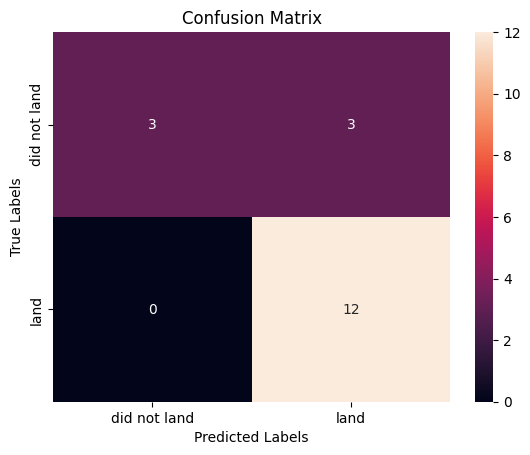

In [11]:
y_hat = logreg_cv.predict(x_test)
plot_confusion_matrix(y_test, y_hat)

True positive: 12 (true label is landed, predicted label is also landed)

False positive: 3 (true label is not landed, predicted label is landed)

<h3 style = 'color: yellow'>Task6: create a support vector machine object then create a GridSearchCV object svm_cv with cv = 10. fit the object to find the best parameters from the dictionary parameters</h3>

In [12]:
parameters_svc = {'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid'),
                  'C': np.logspace(-3, 3, 5),
                  'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(estimator = svm,
                      param_grid = parameters_svc,
                      cv = 10,
                      scoring = 'accuracy',
                      verbose = 2)
svm_cv.fit(x_train, y_train)
print('tuned hpyerparameters: (best parameters) ', svm_cv.best_params_)
print('accuracy :', svm_cv.best_score_)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ...................C=0.001, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.001, gamma=0

<h3 style = 'color: yellow'>Task7: calculate the accuracy on the test data using the method score</h3>

In [13]:
score_svm = svm_cv.score(x_test, y_test)
score_svm

0.8333333333333334

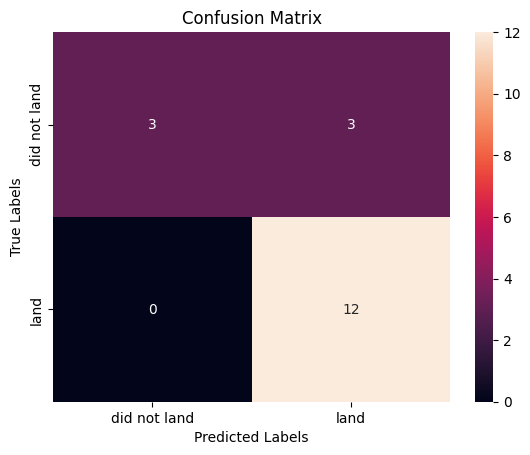

In [14]:
y_hat = svm_cv.predict(x_test)
plot_confusion_matrix(y_test, y_hat)

<h3 style = 'color: yellow'>Task8: create a decision tree classifier object then create a GridSearchCV object tree_cv with cv = 10.</h3>

In [17]:
parameters_tree = {'criterion': ['gini', 'entropy'],
                   'splitter': ['best', 'random'],
                   'max_depth': [2*n for n in range(1, 10)],
                   'max_features': ['auto', 'sqrt'],
                   'min_samples_leaf': [1, 2, 4],
                   'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(estimator = tree,
                       param_grid = parameters_tree,
                       cv = 10,
                       scoring = 'accuracy',
                       verbose = 2)
tree_cv.fit(x_train, y_train)
print('tuned hpyerparameters: (best parameters) ', tree_cv.best_params_)
print('accuracy :', tree_cv.best_score_)

Fitting 10 folds for each of 648 candidates, totalling 6480 fits
[CV] END criterion=gini, max_depth=2, max_features=auto, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=auto, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=auto, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=auto, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=auto, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=auto, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=auto, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END cr

C:\Users\Sammi Wang\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Sammi Wang\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Sammi Wang\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Sammi Wang\AppData\Local\Programs\Python\Python312\Lib\sit

In [18]:
score_tree = tree_cv.score(x_test, y_test)
score_tree

0.8333333333333334

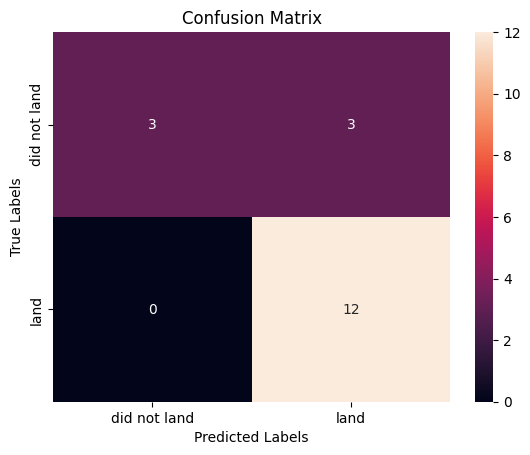

In [19]:
y_hat = tree_cv.predict(x_test)
plot_confusion_matrix(y_test, y_hat)

<h3 style = 'color: yellow'>Task10: create a k nearest neighbors object then create a GridSearchCV object knn_cv with cv = 10</h3>

In [20]:
parameters_knn = {'n_neighbors': [i for i in range(1, 11)],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(estimator = knn,
                      param_grid = parameters_knn,
                      cv = 10,
                      scoring = 'accuracy',
                      verbose = 2)
knn_cv.fit(x_train, y_train)
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

Fitting 10 folds for each of 80 candidates, totalling 800 fits
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.1s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=1; total time=   0.0s
[CV] END .................algorithm=auto, n_neighbors=1, p=2; total time=   0.0s
[CV] END .................algorithm=auto, n_ne

In [21]:
score_knn = knn_cv.score(x_test, y_test)
score_knn

0.8333333333333334

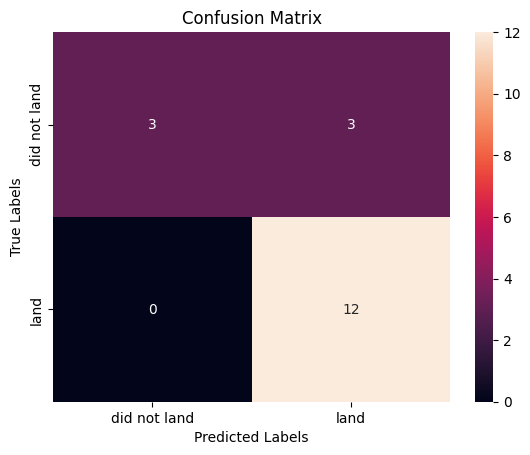

In [22]:
y_hat = knn_cv.predict(x_test)
plot_confusion_matrix(y_test, y_hat)